In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('Sample - Superstore.csv', encoding='latin1')

# Preview the data
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
# Check the shape of data (rows, columns)
print("Dataset shape:", df.shape)

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

# Check data types
print("\nData types:")
print(df.dtypes)

Dataset shape: (9994, 21)

Missing values:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Data types:
Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code        int64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: 

In [5]:
# Convert Order Date to proper date format
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Extract year and month for trend analysis later
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

print("Date fixed! Here's a preview:")
print(df[['Order Date', 'Year', 'Month']].head())

Date fixed! Here's a preview:
  Order Date  Year  Month
0 2016-11-08  2016     11
1 2016-11-08  2016     11
2 2016-06-12  2016      6
3 2015-10-11  2015     10
4 2015-10-11  2015     10


In [6]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_orders = df['Order ID'].nunique()
profit_margin = (total_profit / total_sales) * 100

print("===== KEY BUSINESS METRICS =====")
print(f"Total Revenue:    ${total_sales:,.2f}")
print(f"Total Profit:     ${total_profit:,.2f}")
print(f"Total Orders:     {total_orders}")
print(f"Profit Margin:    {profit_margin:.2f}%")

===== KEY BUSINESS METRICS =====
Total Revenue:    $2,297,200.86
Total Profit:     $286,397.02
Total Orders:     5009
Profit Margin:    12.47%


C:\Users\judyy\AppData\Local\Temp\ipykernel_5104\1799319914.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_sales.index, y=category_sales.values, palette='viridis')


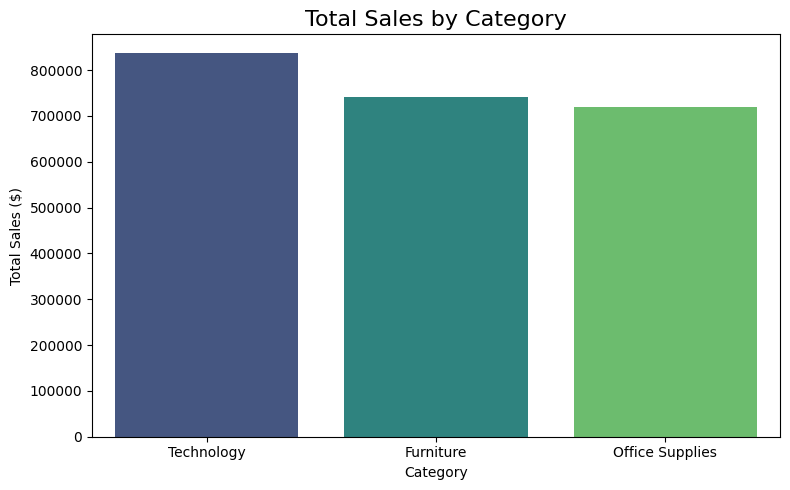

In [7]:
plt.figure(figsize=(8,5))
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
sns.barplot(x=category_sales.index, y=category_sales.values, palette='viridis')
plt.title('Total Sales by Category', fontsize=16)
plt.xlabel('Category')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.savefig('sales_by_category.png')
plt.show()

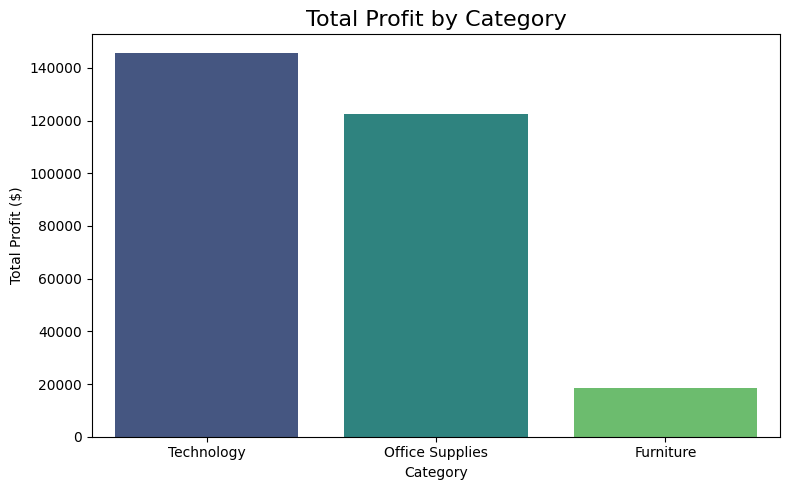

In [8]:
plt.figure(figsize=(8,5))
category_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)
sns.barplot(x=category_profit.index, y=category_profit.values, hue=category_profit.index, palette='viridis', legend=False)
plt.title('Total Profit by Category', fontsize=16)
plt.xlabel('Category')
plt.ylabel('Total Profit ($)')
plt.tight_layout()
plt.savefig('profit_by_category.png')
plt.show()

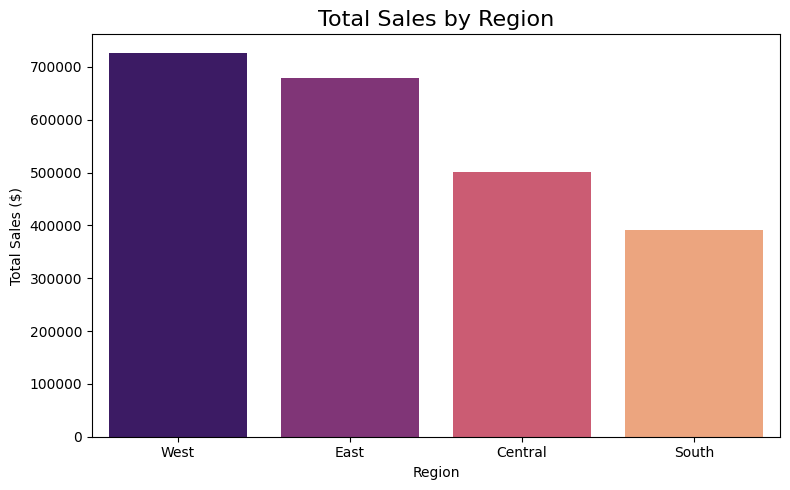

In [9]:
plt.figure(figsize=(8,5))
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
sns.barplot(x=region_sales.index, y=region_sales.values, hue=region_sales.index, palette='magma', legend=False)
plt.title('Total Sales by Region', fontsize=16)
plt.xlabel('Region')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.savefig('sales_by_region.png')
plt.show()

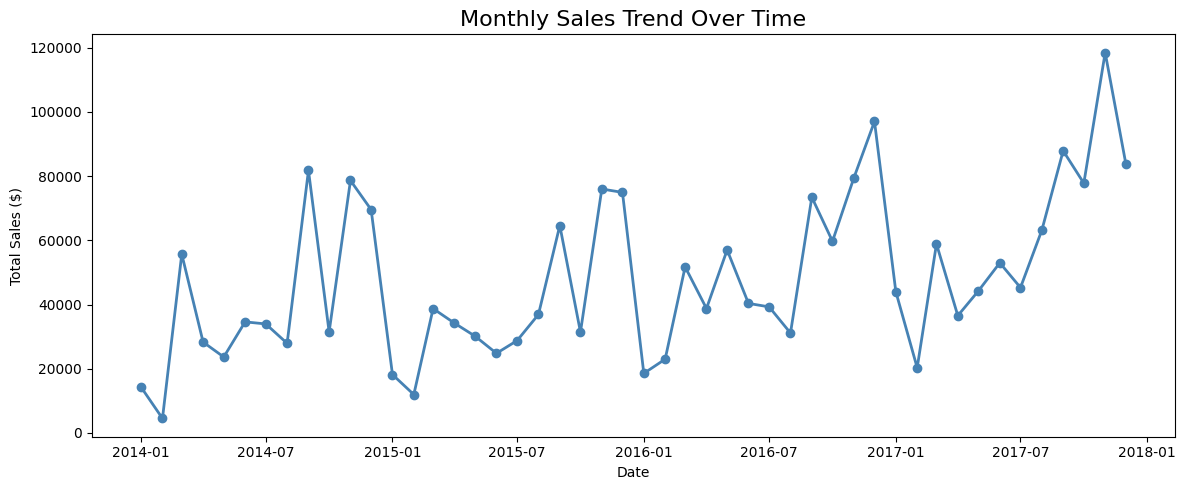

In [10]:
plt.figure(figsize=(12,5))
monthly_sales = df.groupby(['Year', 'Month'])['Sales'].sum().reset_index()
monthly_sales['Date'] = pd.to_datetime(monthly_sales[['Year', 'Month']].assign(day=1))
plt.plot(monthly_sales['Date'], monthly_sales['Sales'], marker='o', color='steelblue', linewidth=2)
plt.title('Monthly Sales Trend Over Time', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.savefig('sales_trend.png')
plt.show()

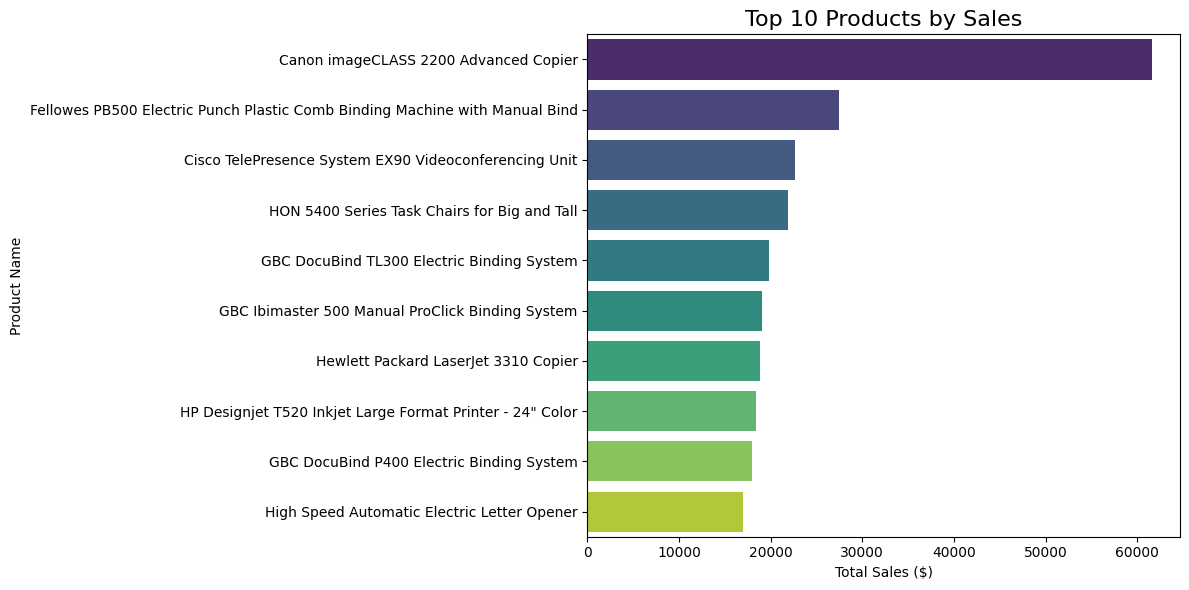

In [11]:
plt.figure(figsize=(12,6))
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_products.values, y=top_products.index, hue=top_products.index, palette='viridis', legend=False)
plt.title('Top 10 Products by Sales', fontsize=16)
plt.xlabel('Total Sales ($)')
plt.ylabel('Product Name')
plt.tight_layout()
plt.savefig('top_products.png')
plt.show()

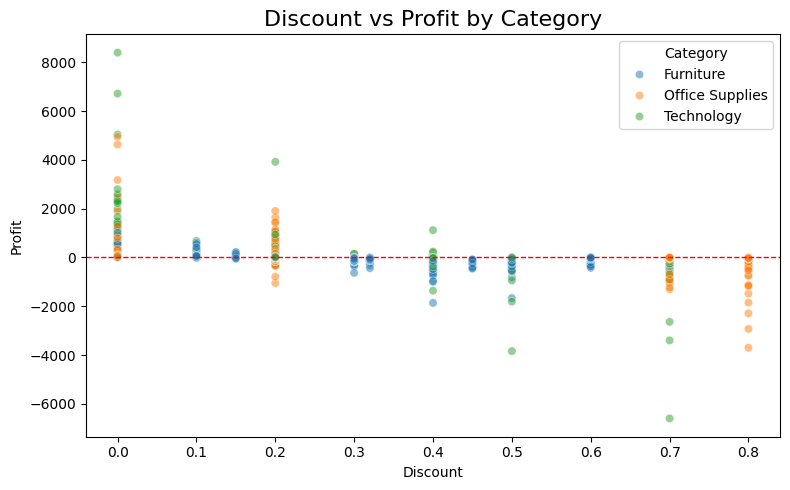

In [12]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Discount', y='Profit', hue='Category', alpha=0.5)
plt.title('Discount vs Profit by Category', fontsize=16)
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.tight_layout()
plt.savefig('discount_vs_profit.png')
plt.show()

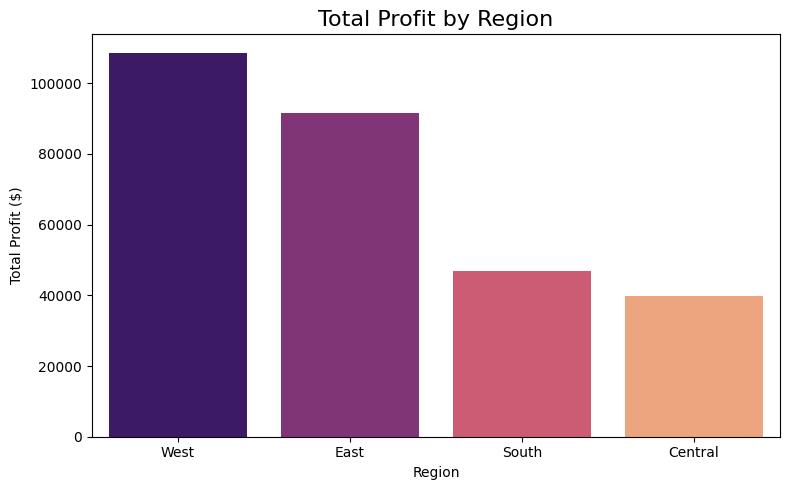

In [13]:
plt.figure(figsize=(8,5))
region_profit = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)
sns.barplot(x=region_profit.index, y=region_profit.values, hue=region_profit.index, palette='magma', legend=False)
plt.title('Total Profit by Region', fontsize=16)
plt.xlabel('Region')
plt.ylabel('Total Profit ($)')
plt.tight_layout()
plt.savefig('profit_by_region.png')
plt.show()

# Business sales performance analysis — Key insights & recommendations

## Dataset overview
- Total revenue: $2,297,200.86
- Total profit: $286,397.02
- Total orders: 5,009
- Profit margin: 12.47%

## Key findings

### 1. Technology is the star category
Technology leads in both sales AND profit. The Canon imageCLASS 2200 Copier alone 
is the #1 selling product by a huge margin. The business should continue investing here.

### 2. Furniture is a hidden problem
Furniture ranks #2 in sales but dead last in profit. It generates high revenue but 
barely any return , suggesting heavy discounting is eating into margins.

### 3. Discounts above 40% are losing money
The scatter plot clearly shows that any discount above 0.4 almost always results 
in negative profit. The business is essentially paying customers to take products.

### 4. West region is the top performer
West leads in both sales and profit. South and Central are underperforming 
and need targeted sales strategies.

### 5. Sales are growing year over year
Clear upward trend from 2014 to 2017, with consistent end-of-year spikes 
(holiday season effect).

## Recommendations
1. Cap discounts at 30% —> anything above is costing the business money
2. Review Furniture pricing strategy —> high sales volume should translate to better profit
3. Invest more in Technology —> highest ROI category
4. Focus growth efforts on South and Central regions —> biggest opportunity gap
5. Plan inventory and campaigns around Q4 —> sales consistently peak at year end